In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipynb.fs.full.Error_Propagation import find_effective_dieletric,find_f0_Conformal_Mapping,delta_k0,delta_elleptical_int,delta_e_eff,delta_L_C_conformal_mapping,find_Kinetic_Inductance_Resistance,delta_Kinetic_Inductance,delta_frequency,delta_frequency_london


In [10]:
mu_0 = 4*np.pi*10**-7  

In [11]:
#Resonator Lengths
l1 = 556.1*10**-6
l2 = 636.1*10**-6
l3 = 580.1*10**-6
l4 = 668.1*10**-6
l5 = 607.1*10**-6
l6 = 538.8*10**-6
l_vals = np.array([l1,l2,l3,l4,l5,l6])
dl_vals = np.ones(len(l_vals))*0.2*10**-6

#Substrate Height
h_s = 500*10**-6
dh_s = 1*10**-6

#CPW width
w_CPW = 20*10**-6
dw_CPW = 2*10**-6

#Cryo Sapphire dielectric constant
e_sap = 10.1

#Dimensions of CPW
central_width = 10*(10**-6)
dcentral_width = 1*(10**-6)
seperation = 5*(10**-6)
dseperation = 1*(10**-6)

# Parameters taken from James Potters Thesis for NbN
Temp = 10*10**-3
dTemp = 200*10**-3
NbN_Tc = 9
NbN_dTc = 0.1
NbN_lambda_L = 1145*10**-9
NbN_dlambda_L = 1*10**-9
NbN_R_sq= 1.075*10**3
NbN_dR_sq = 0.001*10**3

# Thicknes array
thickness = 10*10**-9
dthickness = 1*10**-9
thickness_arr = np.array([10,9,8,7,6,5])*10**-9

In [12]:
#############################
# All Results in GHz
#############################

#Simulation Results - EPA 1
sim_EPA1_10nm = np.array([5.46201,4.33502,4.78786,np.nan,5.59638,6.18263])
sim_EPA1_9nm =  np.array([6.17691,5.38595,5.86495,4.94974,5.83643,6.28143])
sim_EPA1_8nm =  np.array([5.83518,5.08216,5.54249,4.66739,5.50951,5.94709])
sim_EPA1_7nm =  np.array([5.46705,4.76397,5.19388,4.37489,5.16244,5.57265])
sim_EPA1_6nm =  np.array([5.07058,4.41834,np.nan,4.09509,np.nan,5.16967])
sim_EPA1_5nm =  np.array([4.63593,4.04029,4.37227,4.27335,4.37800,4.72606])

#EPA 2
sim_EPA2_10nm = np.array([7.73743,6.88451,7.39176,6.57560,7.21628,7.99575])
sim_EPA2_9nm =  np.array([7.35423,6.54387,7.02563,6.25020,6.85901,7.59998])
sim_EPA2_8nm =  np.array([6.94626,6.18136,6.63655,5.90430,6.47921,7.17898])
sim_EPA2_7nm =  np.array([6.51084,5.79369,6.21993,5.53397,6.07270,6.72821])
sim_EPA2_6nm =  np.array([6.03969,5.37472,5.76981,5.13378,5.63356,6.24140])
sim_EPA2_5nm =  np.array([5.52492,4.91686,5.27859,4.69653,5.15272,5.70906])

#EPA 3
sim_EPA3_10nm = np.array([7.99140,7.01413,7.65517,6.70104,7.34165,8.29062])
sim_EPA3_9nm =  np.array([7.59627,6.66714,7.27634,6.36965,6.97848,np.nan])
sim_EPA3_8nm =  np.array([7.17602,6.29819,6.87382,6.20629,6.59286,7.44680])
sim_EPA3_7nm =  np.array([np.nan,np.nan,np.nan,np.nan,np.nan,np.nan])
sim_EPA3_6nm =  np.array([6.23986,5.47622,5.97672,5.23231,5.73245,6.47045])
sim_EPA3_5nm =  np.array([5.70780,5.00936,5.46707,4.78652,5.24460,5.91927])


<Figure size 640x480 with 0 Axes>

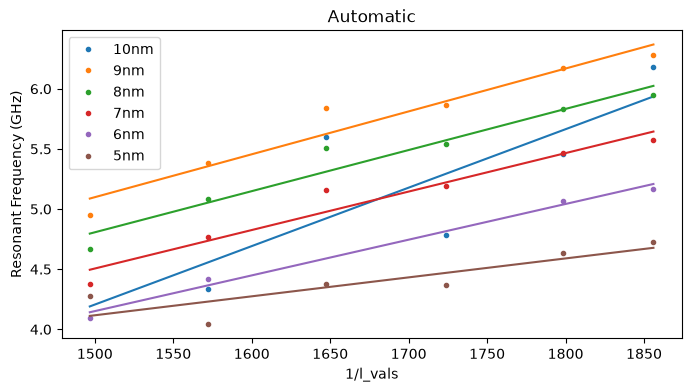

<Figure size 640x480 with 0 Axes>

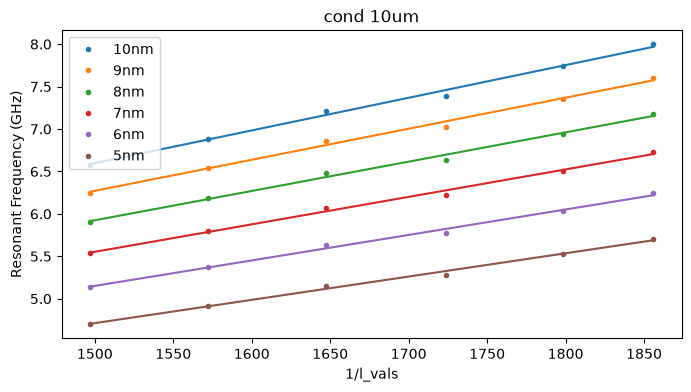

<Figure size 640x480 with 0 Axes>

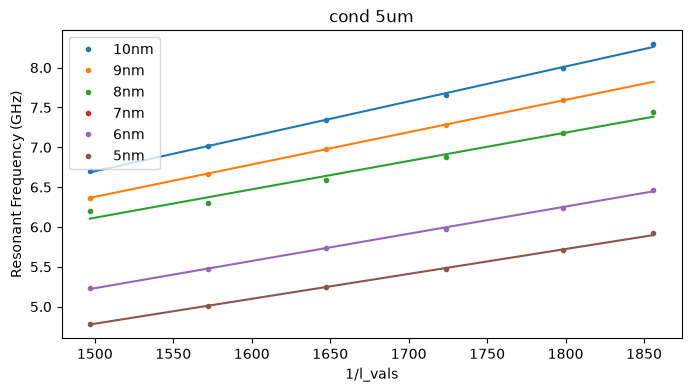

In [13]:
epa_groups = {
    "Automatic": {"10nm": sim_EPA1_10nm, "9nm": sim_EPA1_9nm, "8nm": sim_EPA1_8nm,
              "7nm": sim_EPA1_7nm, "6nm": sim_EPA1_6nm, "5nm": sim_EPA1_5nm},
    "cond 10um": {"10nm": sim_EPA2_10nm, "9nm": sim_EPA2_9nm, "8nm": sim_EPA2_8nm,
              "7nm": sim_EPA2_7nm, "6nm": sim_EPA2_6nm, "5nm": sim_EPA2_5nm},
    "cond 5um": {"10nm": sim_EPA3_10nm, "9nm": sim_EPA3_9nm, "8nm": sim_EPA3_8nm,
              "7nm": sim_EPA3_7nm, "6nm": sim_EPA3_6nm, "5nm": sim_EPA3_5nm},
}

x = 1 / l_vals

for epa_name, arrs in epa_groups.items():
    plt.figure()
    plt.figure(figsize=(8, 4))
    for label, arr in arrs.items():
        mask = ~np.isnan(arr)
        pts = plt.plot(x, arr, '.', label=label)
        color = pts[0].get_color()

        if mask.sum() >= 2:  # need at least 2 points to fit a line
            m, b = np.polyfit(x[mask], arr[mask], 1)
            x_fit = np.linspace(x.min(), x.max(), 100)
            plt.plot(x_fit, m*x_fit + b, '-', color=color)

    plt.xlabel("1/l_vals")
    plt.ylabel("Resonant Frequency (GHz)")
    plt.title(epa_name)
    plt.legend()
    plt.show()

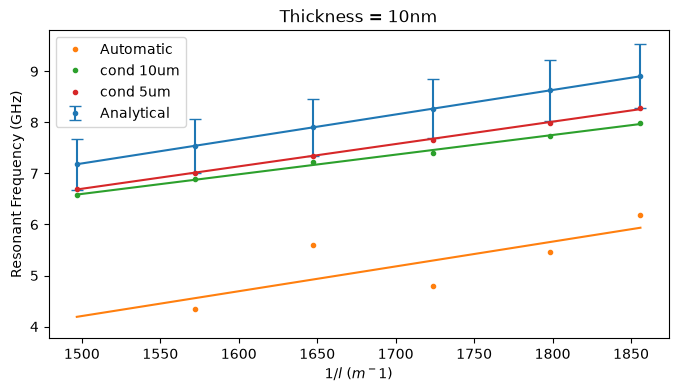

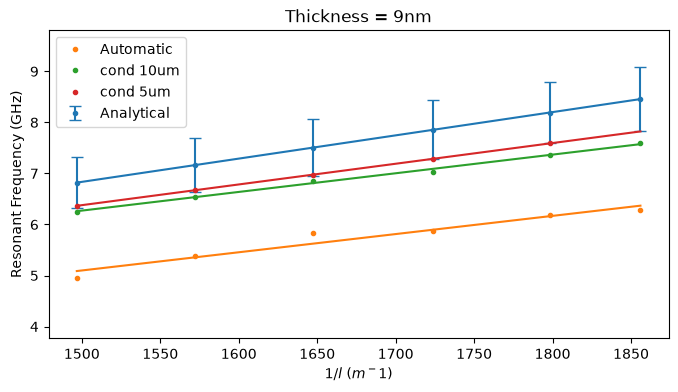

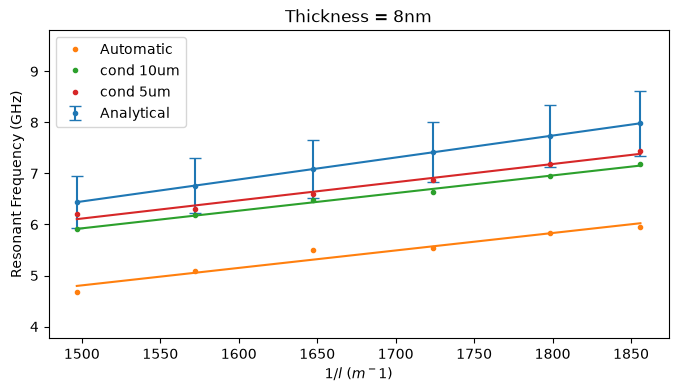

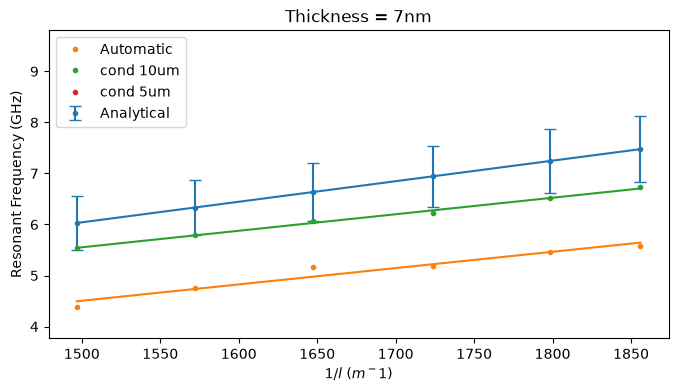

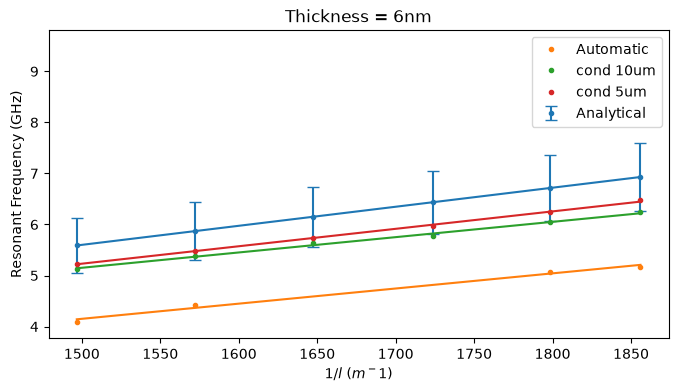

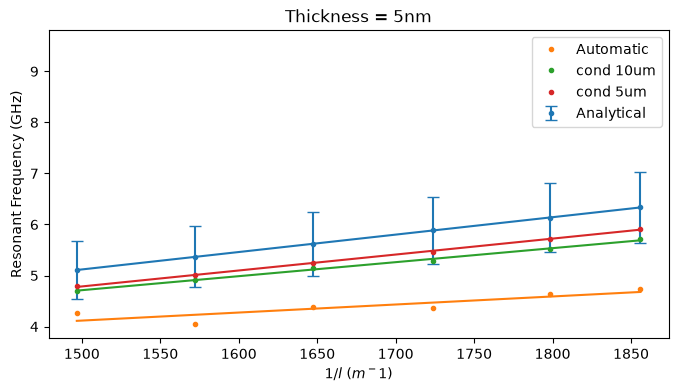

In [14]:
thickness_labels = ["10nm","9nm","8nm","7nm","6nm","5nm"]

# --- First pass: collect all y-values to find a common axis scale ---
all_y_vals = []
theo_cache = {}

for t, label in zip(thickness_arr, thickness_labels):
    f0_t, df0_t = delta_frequency_london(central_width, seperation, e_sap, h_s, w_CPW, l_vals,
                                      t, Temp, NbN_Tc, NbN_lambda_L,
                                      dcentral_width, dseperation, dh_s, dw_CPW, dl_vals,
                                      dthickness, dTemp, NbN_dTc, NbN_dlambda_L)
    f0_t = f0_t / 10**9
    df0_t = df0_t / 10**9
    theo_cache[label] = (f0_t, df0_t)

    all_y_vals.append(f0_t + df0_t)
    all_y_vals.append(f0_t - df0_t)

    for epa_name, arrs in epa_groups.items():
        arr = arrs[label]
        mask = ~np.isnan(arr)
        all_y_vals.append(arr[mask])

y_all = np.concatenate(all_y_vals)
y_min, y_max = np.nanmin(y_all), np.nanmax(y_all)
y_pad = 0.05 * (y_max - y_min)
y_lim = (y_min - y_pad, y_max + y_pad)

# --- Second pass: plot with shared y-axis limits ---
for t, label in zip(thickness_arr, thickness_labels):
    plt.figure(figsize=(8, 4))

    f0_t, df0_t = theo_cache[label]

    m, b = np.polyfit(x, f0_t, 1)
    x_fit = np.linspace(x.min(), x.max(), 100)
    pts = plt.errorbar(x, f0_t, yerr=df0_t, capsize=4, fmt='.', label='Analytical')
    plt.plot(x_fit, m*x_fit + b, '-', color=pts[0].get_color())

    for epa_name, arrs in epa_groups.items():
        arr = arrs[label]
        mask = ~np.isnan(arr)
        pts = plt.plot(x, arr, '.', label=epa_name)
        if mask.sum() >= 2:
            m, b = np.polyfit(x[mask], arr[mask], 1)
            plt.plot(x_fit, m*x_fit + b, '-', color=pts[0].get_color())

    plt.xlabel(f'$1/l$ ($m^{-1}$)')
    plt.ylabel("Resonant Frequency (GHz)")
    plt.title(f"Thickness = {label}")
    plt.ylim(y_lim)
    plt.legend()
    plt.show()

In [15]:
theo_by_thickness = {}
for t, label in zip(thickness_arr, thickness_labels):
    f0,df0 = delta_frequency_london(central_width, seperation, e_sap, h_s, w_CPW, l_vals,
                                      t, Temp, NbN_Tc, NbN_lambda_L,
                                      dcentral_width, dseperation, dh_s, dw_CPW, dl_vals,
                                      dthickness, dTemp, NbN_dTc, NbN_dlambda_L)
    theo_by_thickness[label] = f0 / 10**9  # GHz

<Figure size 640x480 with 0 Axes>

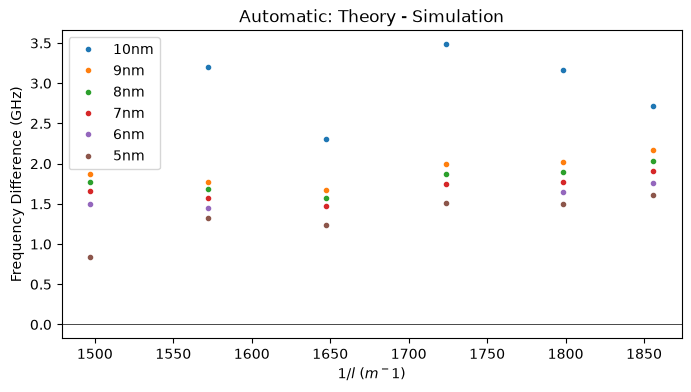

<Figure size 640x480 with 0 Axes>

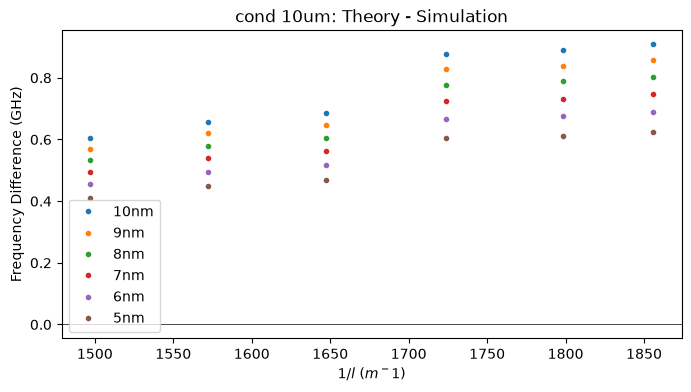

<Figure size 640x480 with 0 Axes>

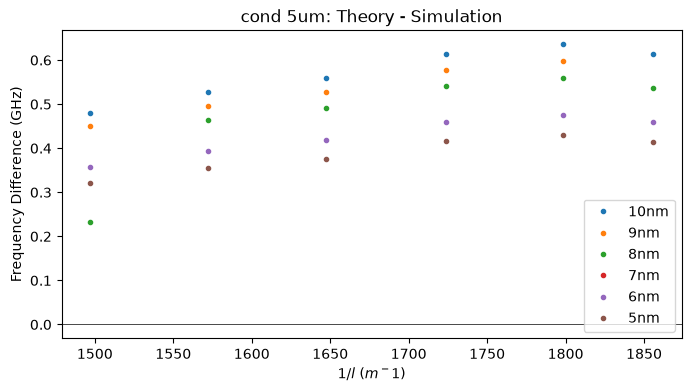

In [16]:
# Theory - Simulation, per EPA, per thickness
for epa_name, arrs in epa_groups.items():
    plt.figure()
    plt.figure(figsize=(8, 4))
    for label, sim_arr in arrs.items():
        diff = theo_by_thickness[label] - sim_arr
        plt.plot(x, diff, '.', label=label)

    plt.xlabel(f'$1/l$ ($m^{-1}$)')
    plt.ylabel("Frequency Difference (GHz)")
    plt.title(f"{epa_name}: Theory - Simulation")
    plt.axhline(0, color='k', linewidth=0.5)
    plt.legend()
    plt.show()